# Task 2: PySpark Big Data Processing (Online Retail II)

This notebook loads the normalized Online Retail II data straight out of PostgreSQL (the same
`customers` / `products` / `invoices` / `invoice_items` tables built in Task 1) into Spark via
JDBC, joins it into one flat DataFrame, cleans/transforms it with Spark DataFrame operations,
computes business KPIs, and demonstrates a partitioning performance improvement.

The combined `invoice_items` table has 1,033,036 rows, which clears the 500,000+ row requirement.

## Spark Setup

Requires a local JDK. This environment has Java 11 installed, so PySpark is pinned to the 3.5.x
line (PySpark 4.x needs Java 17+). `spark.jars.packages` pulls the PostgreSQL JDBC driver from
Maven Central automatically the first time this runs (needs an internet connection once; after
that it's cached locally under `~/.ivy2`).

Partitioned Parquet writes on Windows also need `winutils.exe`/`hadoop.dll` on `HADOOP_HOME` -
without them Spark can't create the output directories for a partitioned write. Both are
installed here (`E:\Hadoop\bin`).

In [2]:
import os

# JAVA_HOME / HADOOP_HOME must be set before the JVM launches. Adjust these paths for your machine.
os.environ.setdefault("JAVA_HOME", r"C:\Program Files\Java\jdk-11.0.16.1")
os.environ.setdefault("HADOOP_HOME", r"E:\Hadoop")
os.environ["PATH"] = os.environ["JAVA_HOME"] + r"\bin;" + os.environ["HADOOP_HOME"] + r"\bin;" + os.environ["PATH"]

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import time

spark = (
    SparkSession.builder
    .appName("OnlineRetailPySparkAnalysis")
    .master("local[*]")
    .config("spark.jars.packages", "org.postgresql:postgresql:42.7.4")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
print("Spark version:", spark.version)

Spark version: 3.5.3


## Load Data from PostgreSQL and Inspect Schema

Each of the four normalized tables is read into Spark via JDBC, then joined into one flat
`fact` DataFrame - this is the Spark-native equivalent of the flat file the dataset started as,
but built from the cleaned relational tables instead of re-parsing the raw Excel file.

In [3]:
JDBC_URL = "jdbc:postgresql://localhost:5432/online_retail"
JDBC_PROPS = {
    "user": os.environ.get("PGUSER", "postgres"),
    "password": os.environ.get("PGPASSWORD", "postgres"),
    "driver": "org.postgresql.Driver",
}

def read_table(name):
    return spark.read.jdbc(url=JDBC_URL, table=name, properties=JDBC_PROPS)

customers = read_table("customers")
products = read_table("products")
invoices = read_table("invoices")
invoice_items = read_table("invoice_items")

for name, df in [("customers", customers), ("products", products),
                  ("invoices", invoices), ("invoice_items", invoice_items)]:
    print(f"{name}: {df.count():,} rows")

invoice_items.printSchema()

customers: 5,942 rows
products: 5,305 rows
invoices: 53,628 rows
invoice_items: 1,033,036 rows
root
 |-- item_id: integer (nullable = true)
 |-- invoice_no: string (nullable = true)
 |-- stock_code: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: decimal(10,2) (nullable = true)
 |-- created_at: timestamp (nullable = true)



In [4]:
fact_raw = (
    invoice_items.alias("ii")
    .join(invoices.alias("i"), F.col("ii.invoice_no") == F.col("i.invoice_no"))
    .join(customers.alias("c"), F.col("i.customer_id") == F.col("c.customer_id"))
    .join(products.alias("p"), F.col("ii.stock_code") == F.col("p.stock_code"))
    .select(
        "ii.item_id", "ii.invoice_no", "ii.stock_code", "p.description",
        "ii.quantity", "ii.unit_price", "i.invoice_date", "i.is_cancelled",
        "c.customer_id", "c.country",
    )
)
print(f"fact_raw rows: {fact_raw.count():,}")
fact_raw.printSchema()

fact_raw rows: 1,033,036
root
 |-- item_id: integer (nullable = true)
 |-- invoice_no: string (nullable = true)
 |-- stock_code: string (nullable = true)
 |-- description: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: decimal(10,2) (nullable = true)
 |-- invoice_date: timestamp (nullable = true)
 |-- is_cancelled: boolean (nullable = true)
 |-- customer_id: integer (nullable = true)
 |-- country: string (nullable = true)



## Clean and Transform

At least three meaningful transformations, all done with Spark DataFrame operations (not Pandas):

1. **`revenue`** - `quantity * unit_price` for each line item.
2. **Date parts** - year, month, day, and hour extracted from `invoice_date`.
3. **Country standardisation** - a handful of country values are abbreviations or non-country
   placeholders in the raw data (`RSA`, `USA`, `EIRE`, `Unspecified`); these are mapped to
   consistent full names (or left flagged) so country-level KPIs don't fragment.

`is_cancelled` is already a clean boolean column from the `invoices` table (derived in Task 1's
cleaning step from invoice numbers starting with `'C'`), so no missing/invalid values remain to
handle at this stage - that was done upstream in `Task 1/cleaning/clean_dataset.py`.

In [5]:
fact = (
    fact_raw
    .withColumn("revenue", F.col("quantity") * F.col("unit_price"))
    .withColumn("year", F.year("invoice_date"))
    .withColumn("month", F.month("invoice_date"))
    .withColumn("day", F.dayofmonth("invoice_date"))
    .withColumn("hour", F.hour("invoice_date"))
    .withColumn(
        "country_clean",
        F.when(F.col("country") == "RSA", "South Africa")
         .when(F.col("country") == "USA", "United States")
         .when(F.col("country") == "EIRE", "Ireland")
         .otherwise(F.trim(F.col("country")))
    )
)

fact.select("invoice_no", "quantity", "unit_price", "revenue", "invoice_date",
            "year", "month", "day", "hour", "country", "country_clean").show(5)

print("Distinct raw countries:", fact.select("country").distinct().count())
print("Distinct standardised countries:", fact.select("country_clean").distinct().count())

+----------+--------+----------+-------+-------------------+----+-----+---+----+--------------+--------------+
|invoice_no|quantity|unit_price|revenue|       invoice_date|year|month|day|hour|       country| country_clean|
+----------+--------+----------+-------+-------------------+----+-----+---+----+--------------+--------------+
|    489677|      24|      4.25| 102.00|2009-12-02 09:50:00|2009|   12|  2|   9|United Kingdom|United Kingdom|
|    489677|      24|      3.75|  90.00|2009-12-02 09:50:00|2009|   12|  2|   9|United Kingdom|United Kingdom|
|    490460|      -2|      6.35| -12.70|2009-12-06 12:06:00|2009|   12|  6|  12|United Kingdom|United Kingdom|
|    491037|      -5|      5.95| -29.75|2009-12-09 09:28:00|2009|   12|  9|   9|United Kingdom|United Kingdom|
|    491045|      48|      2.75| 132.00|2009-12-09 10:02:00|2009|   12|  9|  10|United Kingdom|United Kingdom|
+----------+--------+----------+-------+-------------------+----+-----+---+----+--------------+--------------+
o

## Visualization Setup

Every KPI below is charted right after it's computed. Spark DataFrames are small once
aggregated (a few rows to a few thousand), so each result is pulled to Pandas with
`.toPandas()` and plotted with Matplotlib - Spark does the heavy lifting, Matplotlib just
renders the already-aggregated summary.

The palette and chart chrome (colors, gridlines, spacing) are fixed once here and reused
by every chart so the notebook reads as one consistent visual system rather than a
default-styled plot per cell.

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Chart palette (categorical hue order + status color), see dataviz reference palette.
COLOR_BLUE = "#2a78d6"      # sequential hue / categorical slot 1 - magnitude bars, primary series
COLOR_ORANGE = "#eb6834"    # categorical slot 2 - secondary series
COLOR_RED = "#d03b3b"       # status: critical - cancellations only

INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"
SURFACE = "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK_SECONDARY,
    "text.color": INK_PRIMARY,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "axes.grid": True,
    "grid.color": GRIDLINE,
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.spines.bottom": True,
    "font.size": 11,
    "figure.dpi": 110,
})


def style_ax(ax, title, ylabel=None, horizontal=False):
    """Shared chart chrome: left-aligned bold title, muted recessive gridlines, no clutter."""
    ax.set_title(title, fontsize=13, fontweight="bold", color=INK_PRIMARY, pad=12, loc="left")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=10)
    if horizontal:
        ax.xaxis.grid(True)
        ax.yaxis.grid(False)
    else:
        ax.yaxis.grid(True)
        ax.xaxis.grid(False)
    ax.tick_params(length=0)


def money_fmt(v, _pos=None):
    return f"£{v/1000:,.0f}k" if abs(v) >= 1000 else f"£{v:,.0f}"

## Business KPI 1: Total Revenue by Month

The same monthly trend as Task 1's SQL version, but computed with Spark DataFrame `groupBy`/`agg`
over the joined fact table. Cancelled invoices are excluded so this reflects completed sales.

In [7]:
kpi_monthly_revenue = (
    fact.where(~F.col("is_cancelled"))
    .groupBy("year", "month")
    .agg(F.round(F.sum("revenue"), 2).alias("total_revenue"),
         F.countDistinct("invoice_no").alias("num_invoices"))
    .orderBy("year", "month")
)
kpi_monthly_revenue.show(30)

+----+-----+-------------+------------+
|year|month|total_revenue|num_invoices|
+----+-----+-------------+------------+
|2009|   12|    822483.95|        1929|
|2010|    1|    651155.11|        1333|
|2010|    2|    551504.72|        1729|
|2010|    3|    830915.26|        1960|
|2010|    4|    625280.89|        1588|
|2010|    5|    657705.50|        2011|
|2010|    6|    749537.31|        1859|
|2010|    7|    604778.48|        1673|
|2010|    8|    695251.91|        1604|
|2010|    9|    921696.99|        2004|
|2010|   10|   1122976.35|        2489|
|2010|   11|   1464293.14|        3093|
|2010|   12|    821452.73|        1699|
|2011|    1|    689811.61|        1216|
|2011|    2|    522545.56|        1174|
|2011|    3|    716215.26|        1665|
|2011|    4|    536968.49|        1504|
|2011|    5|    769296.61|        1848|
|2011|    6|    760547.01|        1683|
|2011|    7|    718076.12|        1657|
|2011|    8|    735717.26|        1459|
|2011|    9|   1056435.19|        1994|


**Explanation:** Revenue builds through the second half of each year and peaks around
September-November ahead of the Christmas selling season, then drops off in December (the raw
data's December windows are partial in both years). Useful for staffing and inventory planning.

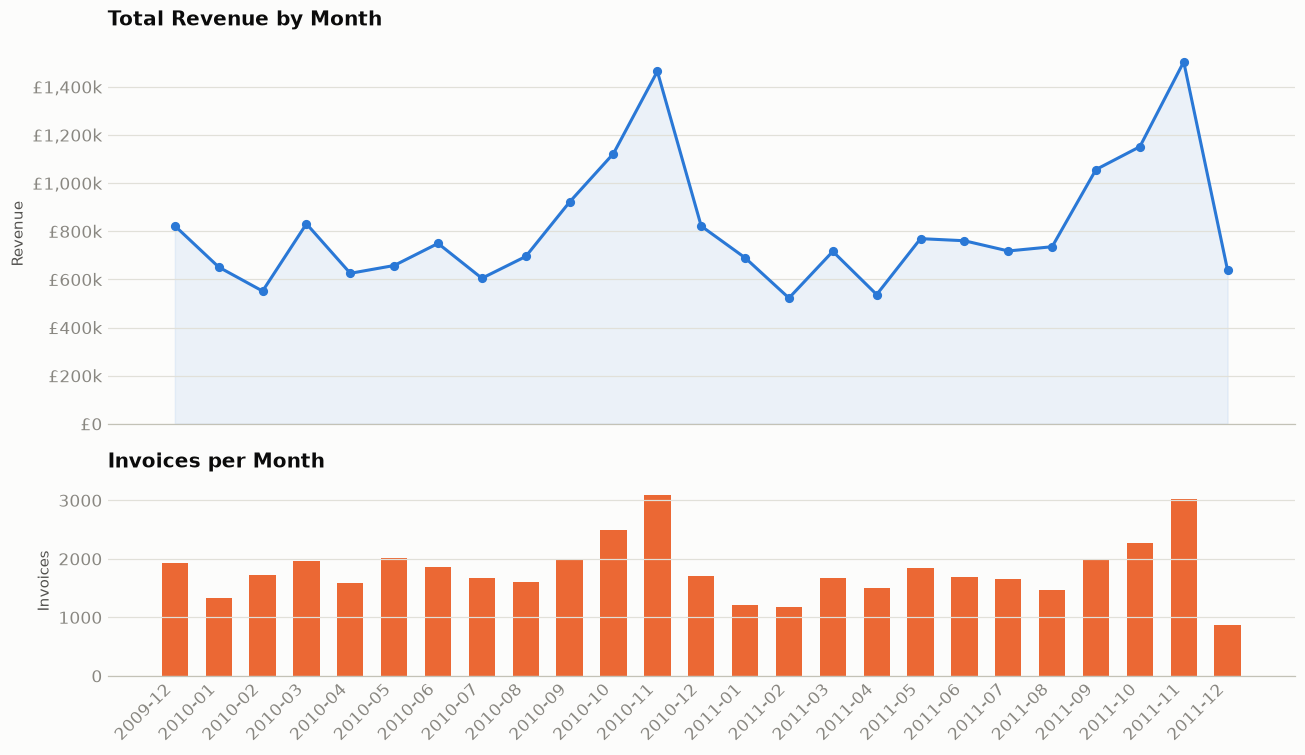

In [8]:
monthly_pd = kpi_monthly_revenue.toPandas()
monthly_pd["period"] = monthly_pd["year"].astype(str) + "-" + monthly_pd["month"].astype(str).str.zfill(2)
monthly_pd["total_revenue"] = monthly_pd["total_revenue"].astype(float)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

axes[0].plot(monthly_pd["period"], monthly_pd["total_revenue"],
             color=COLOR_BLUE, linewidth=2, marker="o", markersize=5, markerfacecolor=COLOR_BLUE)
axes[0].fill_between(monthly_pd["period"], monthly_pd["total_revenue"], color=COLOR_BLUE, alpha=0.08)
style_ax(axes[0], "Total Revenue by Month", "Revenue")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))
axes[0].set_ylim(bottom=0)

axes[1].bar(monthly_pd["period"], monthly_pd["num_invoices"], color=COLOR_ORANGE, width=0.6)
style_ax(axes[1], "Invoices per Month", "Invoices")

axes[1].tick_params(axis="x", rotation=45)
for label in axes[1].get_xticklabels():
    label.set_ha("right")

plt.tight_layout()
plt.show()

## Business KPI 2: Average Order Value

Average revenue per invoice, i.e. total revenue divided by number of distinct invoices, computed
in two steps: first collapse to one row per invoice, then average that.

In [9]:
order_totals = (
    fact.where(~F.col("is_cancelled"))
    .groupBy("invoice_no")
    .agg(F.sum("revenue").alias("order_value"))
)
avg_order_value = order_totals.agg(F.round(F.avg("order_value"), 2).alias("avg_order_value"))
avg_order_value.show()

+---------------+
|avg_order_value|
+---------------+
|         448.16|
+---------------+



**Explanation:** This single number is a useful baseline for spotting whether a given
customer or country over- or under-indexes on order size relative to the business as a whole
(compare against Task 1's CTE query, which found the customers sitting above this average).

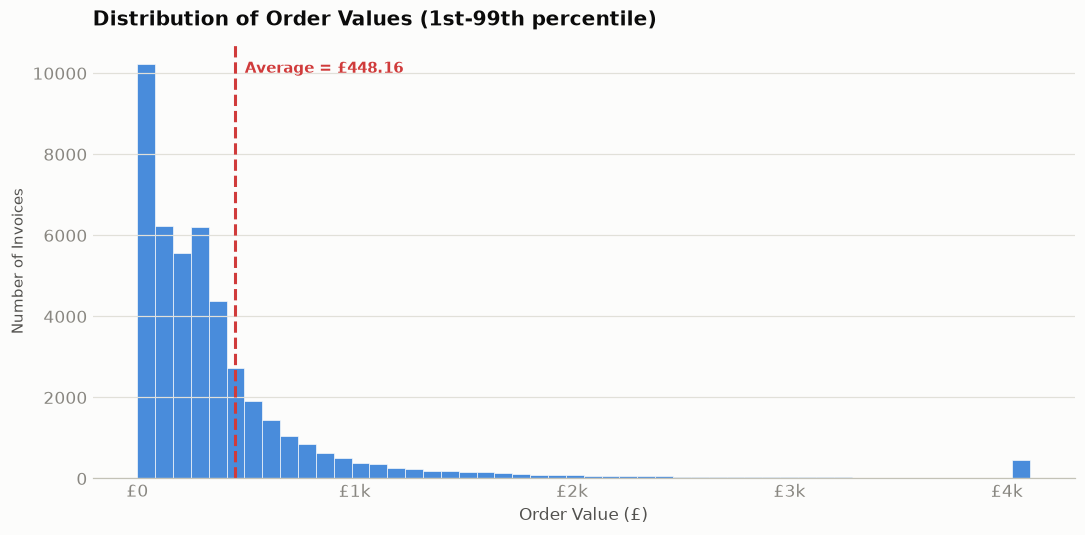

In [10]:
order_pd = order_totals.toPandas()
order_pd["order_value"] = order_pd["order_value"].astype(float)
avg_val = float(avg_order_value.collect()[0]["avg_order_value"])

# Clip to the 1st-99th percentile: a handful of large "adjustment" invoices (bad-debt
# write-offs starting with "A", e.g. -£53,594) and a few huge wholesale orders otherwise
# blow out the axis and crush every normal order into a single bin.
low, high = order_pd["order_value"].quantile([0.01, 0.99])
plot_vals = order_pd["order_value"].clip(lower=low, upper=high)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(plot_vals, bins=50, color=COLOR_BLUE, alpha=0.85, edgecolor=SURFACE, linewidth=0.5)
ax.axvline(avg_val, color=COLOR_RED, linewidth=2, linestyle="--")
ax.text(avg_val, ax.get_ylim()[1] * 0.96, f"  Average = £{avg_val:,.2f}",
        color=COLOR_RED, fontsize=10, fontweight="bold", va="top")
style_ax(ax, "Distribution of Order Values (1st-99th percentile)", "Number of Invoices")
ax.set_xlabel("Order Value (£)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))

plt.tight_layout()
plt.show()

## Business KPI 3: Top 10 Customers by Spend

Highest-spending customers overall, computed with `groupBy` + `orderBy` + `limit` over the fact
table (a Spark DataFrame equivalent of Task 1's window-function query).

In [11]:
kpi_top_customers = (
    fact.where(~F.col("is_cancelled"))
    .groupBy("customer_id", "country_clean")
    .agg(F.round(F.sum("revenue"), 2).alias("total_spend"))
    .orderBy(F.desc("total_spend"))
    .limit(10)
)
kpi_top_customers.show()

+-----------+--------------+-----------+
|customer_id| country_clean|total_spend|
+-----------+--------------+-----------+
|      18102|United Kingdom|  587301.04|
|      14646|   Netherlands|  530060.88|
|      14156|       Ireland|  315983.47|
|      14911|       Ireland|  291758.91|
|      17450|United Kingdom|  244936.89|
|      13694|United Kingdom|  195640.69|
|      16446|United Kingdom|  173239.47|
|      17511|United Kingdom|  172132.87|
|      16684|United Kingdom|  147178.37|
|      12415|     Australia|  144458.37|
+-----------+--------------+-----------+



**Explanation:** Matches Task 1's SQL result closely (small differences would be expected if
either pipeline handled edge cases differently, since we're now reading the same PostgreSQL
tables through a different engine). The concentration at the top confirms this is a wholesale-
heavy customer base rather than typical individual retail shoppers.

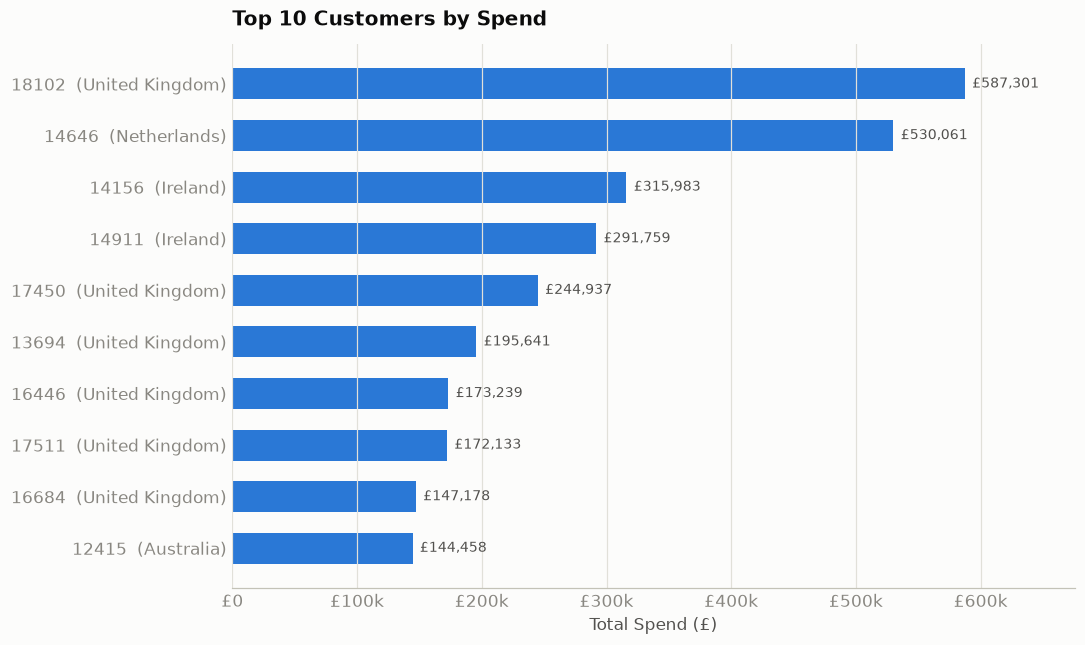

In [12]:
top_cust_pd = kpi_top_customers.toPandas()
top_cust_pd["total_spend"] = top_cust_pd["total_spend"].astype(float)
top_cust_pd["label"] = top_cust_pd["customer_id"].astype(str) + "  (" + top_cust_pd["country_clean"] + ")"
top_cust_pd = top_cust_pd.sort_values("total_spend")  # ascending so highest spender plots at the top

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_cust_pd["label"], top_cust_pd["total_spend"], color=COLOR_BLUE, height=0.6)
style_ax(ax, "Top 10 Customers by Spend", horizontal=True)
ax.set_xlabel("Total Spend (£)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))

max_val = top_cust_pd["total_spend"].max()
for bar, val in zip(bars, top_cust_pd["total_spend"]):
    ax.text(val + max_val * 0.01, bar.get_y() + bar.get_height() / 2,
            f"£{val:,.0f}", va="center", fontsize=9, color=INK_SECONDARY)
ax.set_xlim(right=max_val * 1.15)

plt.tight_layout()
plt.show()

## Business KPI 4: Revenue by Country

Revenue and invoice counts by the standardised country column, showing where the business
actually makes its money.

In [13]:
kpi_country_revenue = (
    fact.where(~F.col("is_cancelled"))
    .groupBy("country_clean")
    .agg(F.countDistinct("invoice_no").alias("num_invoices"),
         F.round(F.sum("revenue"), 2).alias("total_revenue"))
    .orderBy(F.desc("total_revenue"))
)
kpi_country_revenue.show(10)

+--------------+------------+-------------+
| country_clean|num_invoices|total_revenue|
+--------------+------------+-------------+
|United Kingdom|       42207|  17650501.40|
|       Ireland|         650|    646190.10|
|   Netherlands|         230|    550663.51|
|       Germany|         653|    391809.50|
|        France|         554|    274949.44|
|     Australia|          91|    152756.45|
|        Sweden|          80|     82652.66|
|         Spain|         114|     77680.98|
|       Denmark|          49|     67517.30|
|   Switzerland|          56|     58963.10|
+--------------+------------+-------------+
only showing top 10 rows



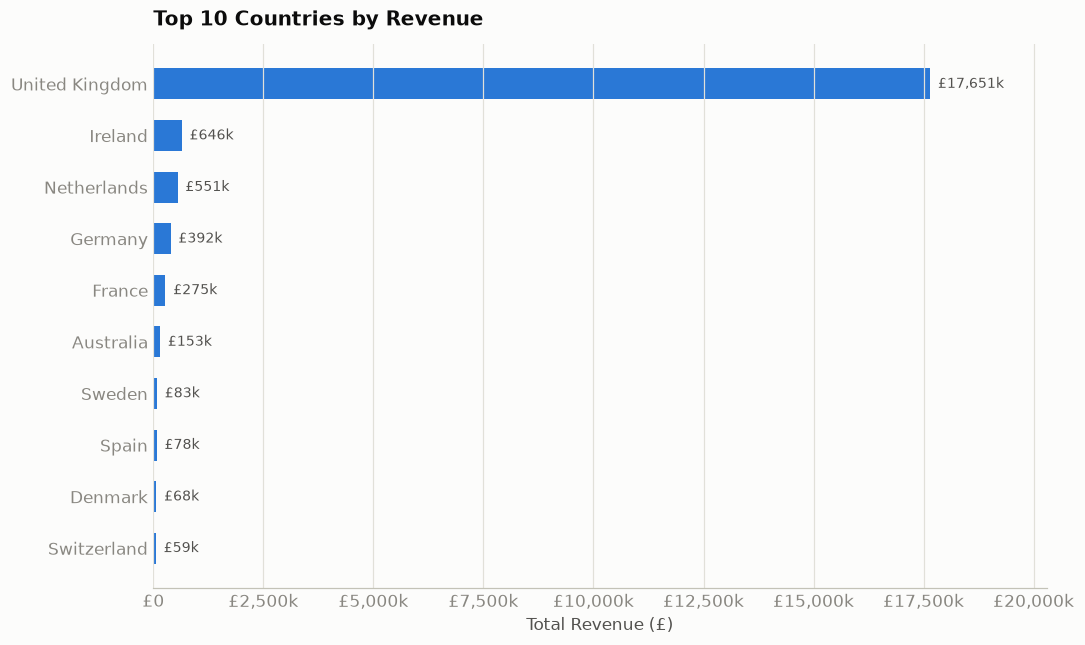

In [14]:
country_pd = kpi_country_revenue.toPandas().head(10)
country_pd["total_revenue"] = country_pd["total_revenue"].astype(float)
country_pd = country_pd.sort_values("total_revenue")  # ascending so the top country plots at the top

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(country_pd["country_clean"], country_pd["total_revenue"], color=COLOR_BLUE, height=0.6)
style_ax(ax, "Top 10 Countries by Revenue", horizontal=True)
ax.set_xlabel("Total Revenue (£)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))

max_val = country_pd["total_revenue"].max()
for bar, val in zip(bars, country_pd["total_revenue"]):
    ax.text(val + max_val * 0.01, bar.get_y() + bar.get_height() / 2,
            money_fmt(val), va="center", fontsize=9, color=INK_SECONDARY)
ax.set_xlim(right=max_val * 1.15)

plt.tight_layout()
plt.show()

**Explanation:** The UK so heavily dominates total revenue (~£17.65M vs. ~£646k for the
next-largest market, Ireland) that a single linear chart flattens every other country into a
sliver. The chart below drops the UK to show the relative shape of the remaining international
markets on their own scale.

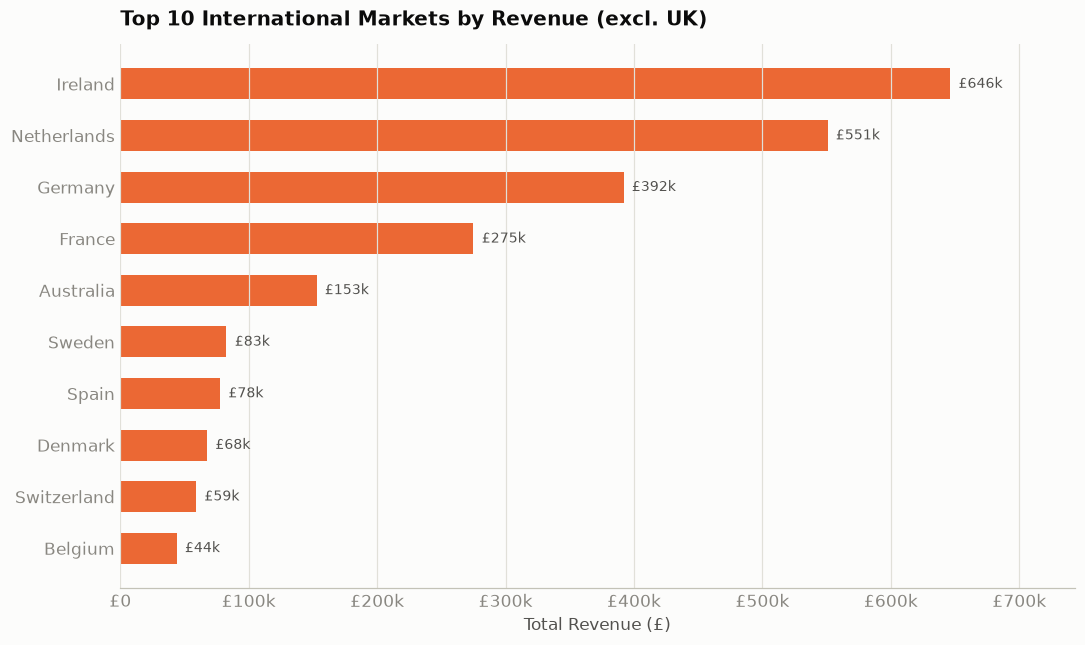

In [15]:
intl_pd = kpi_country_revenue.where(F.col("country_clean") != "United Kingdom").toPandas().head(10)
intl_pd["total_revenue"] = intl_pd["total_revenue"].astype(float)
intl_pd = intl_pd.sort_values("total_revenue")

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(intl_pd["country_clean"], intl_pd["total_revenue"], color=COLOR_ORANGE, height=0.6)
style_ax(ax, "Top 10 International Markets by Revenue (excl. UK)", horizontal=True)
ax.set_xlabel("Total Revenue (£)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))

max_val = intl_pd["total_revenue"].max()
for bar, val in zip(bars, intl_pd["total_revenue"]):
    ax.text(val + max_val * 0.01, bar.get_y() + bar.get_height() / 2,
            money_fmt(val), va="center", fontsize=9, color=INK_SECONDARY)
ax.set_xlim(right=max_val * 1.15)

plt.tight_layout()
plt.show()

## Business KPI 5: Cancellation Rate

Share of invoices that were cancelled, both overall and by product, using the `is_cancelled` flag
straight from the `invoices` table.

In [16]:
total_invoices = fact.select("invoice_no").distinct().count()
cancelled_invoices = fact.where(F.col("is_cancelled")).select("invoice_no").distinct().count()
print(f"Overall cancellation rate: {cancelled_invoices / total_invoices * 100:.2f}% "
      f"({cancelled_invoices:,} of {total_invoices:,} invoices)")

kpi_cancel_by_product = (
    fact.groupBy("stock_code", "description")
    .agg(
        F.count("*").alias("line_items"),
        F.round(F.avg(F.col("is_cancelled").cast("int")) * 100, 2).alias("cancel_rate_pct"),
    )
    .where(F.col("line_items") >= 100)
    .orderBy(F.desc("cancel_rate_pct"))
    .limit(10)
)
kpi_cancel_by_product.show(truncate=False)

Overall cancellation rate: 15.46% (8,292 of 53,628 invoices)
+------------+------------------------+----------+---------------+
|stock_code  |description             |line_items|cancel_rate_pct|
+------------+------------------------+----------+---------------+
|D           |Discount                |173       |97.11          |
|S           |SAMPLES                 |101       |97.03          |
|BANK CHARGES| Bank Charges           |100       |66.0           |
|79323B      |BLACK CHERRY LIGHTS     |111       |45.95          |
|M           |Manual                  |1387      |38.5           |
|79323GR     |GREEN CHERRY LIGHTS     |123       |30.08          |
|79323W      | WHITE CHERRY LIGHTS    |478       |26.36          |
|79323LP     |LIGHT PINK CHERRY LIGHTS|232       |25.86          |
|79323P      |PINK CHERRY LIGHTS      |354       |24.29          |
|79341       |WILLOW BRANCH LIGHTS.   |106       |22.64          |
+------------+------------------------+----------+---------------+



**Explanation:** The overall cancellation rate gives a single health metric for the
business; the per-product breakdown (restricted to products with at least 100 line items so rare
items don't dominate with tiny sample sizes) surfaces specific products worth investigating for
quality or fulfilment issues.

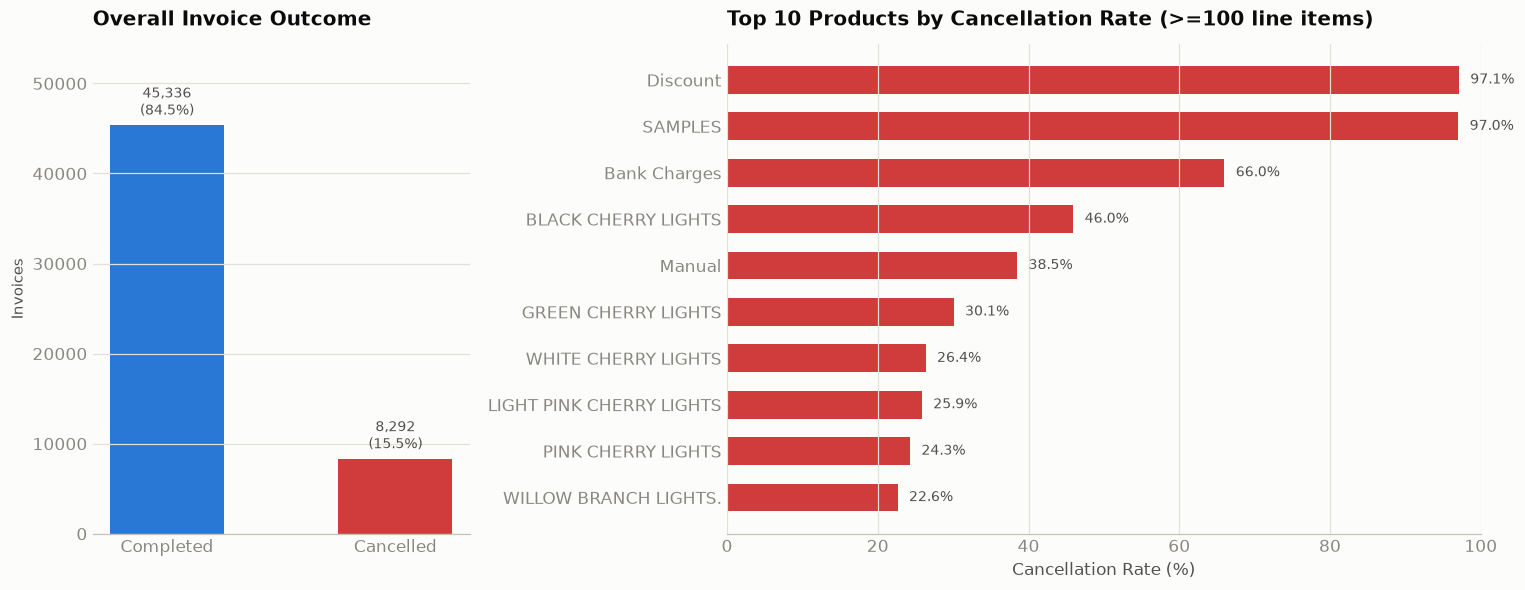

In [17]:
cancel_pd = kpi_cancel_by_product.toPandas()
cancel_pd["cancel_rate_pct"] = cancel_pd["cancel_rate_pct"].astype(float)
cancel_pd["short_desc"] = cancel_pd["description"].str.strip().str.slice(0, 28)
cancel_pd = cancel_pd.sort_values("cancel_rate_pct")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [1, 2]})

# Panel 1: overall cancelled vs. completed invoices (status color reserved for the "bad" state)
labels = ["Completed", "Cancelled"]
values = [total_invoices - cancelled_invoices, cancelled_invoices]
bar_colors = [COLOR_BLUE, COLOR_RED]
bars0 = axes[0].bar(labels, values, color=bar_colors, width=0.5)
style_ax(axes[0], "Overall Invoice Outcome", "Invoices")
for bar, val in zip(bars0, values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + max(values) * 0.015,
                 f"{val:,}\n({val / total_invoices * 100:.1f}%)",
                 ha="center", va="bottom", fontsize=9, color=INK_SECONDARY)
axes[0].set_ylim(top=max(values) * 1.2)

# Panel 2: products with the highest cancellation rate (>=100 line items)
bars1 = axes[1].barh(cancel_pd["short_desc"], cancel_pd["cancel_rate_pct"], color=COLOR_RED, height=0.6)
style_ax(axes[1], "Top 10 Products by Cancellation Rate (>=100 line items)", horizontal=True)
axes[1].set_xlabel("Cancellation Rate (%)")
axes[1].set_xlim(right=100)
for bar, val in zip(bars1, cancel_pd["cancel_rate_pct"]):
    axes[1].text(val + 1.5, bar.get_y() + bar.get_height() / 2,
                 f"{val:.1f}%", va="center", fontsize=9, color=INK_SECONDARY)

plt.tight_layout()
plt.show()

## Spark Performance Evidence: Partitioning and Partition Pruning

The fact table is written to Parquet partitioned by `year` and `month`, then read back. Filtering
for a single year/month is compared before and after partitioning, and the physical plan for the
partitioned read is inspected for `PartitionFilters`.

In [18]:
import shutil

OUTPUT_DIR = "spark_output/fact_partitioned_by_year_month"
shutil.rmtree(OUTPUT_DIR, ignore_errors=True)

target_year, target_month = 2011, 11

start = time.perf_counter()
unpartitioned_count = fact.where((F.col("year") == target_year) & (F.col("month") == target_month)).count()
unpartitioned_seconds = time.perf_counter() - start

fact.write.mode("overwrite").partitionBy("year", "month").parquet(OUTPUT_DIR)
partitioned_df = spark.read.parquet(OUTPUT_DIR)

start = time.perf_counter()
partitioned_count = partitioned_df.where((F.col("year") == target_year) & (F.col("month") == target_month)).count()
partitioned_seconds = time.perf_counter() - start

print(f"Unpartitioned filter (year={target_year}, month={target_month}): "
      f"{unpartitioned_count:,} rows in {unpartitioned_seconds:.3f}s")
print(f"Partitioned filter (year={target_year}, month={target_month}): "
      f"{partitioned_count:,} rows in {partitioned_seconds:.3f}s")

partitioned_df.where((F.col("year") == target_year) & (F.col("month") == target_month)).explain()

Unpartitioned filter (year=2011, month=11): 83,343 rows in 1.984s
Partitioned filter (year=2011, month=11): 83,343 rows in 0.683s
== Physical Plan ==
*(1) ColumnarToRow
+- FileScan parquet [item_id#1405,invoice_no#1406,stock_code#1407,description#1408,quantity#1409,unit_price#1410,invoice_date#1411,is_cancelled#1412,customer_id#1413,country#1414,revenue#1415,day#1416,hour#1417,country_clean#1418,year#1419,month#1420] Batched: true, DataFilters: [], Format: Parquet, Location: InMemoryFileIndex(1 paths)[file:/C:/Users/vahaj/spark_output/fact_partitioned_by_year_month], PartitionFilters: [isnotnull(year#1419), isnotnull(month#1420), (year#1419 = 2011), (month#1420 = 11)], PushedFilters: [], ReadSchema: struct<item_id:int,invoice_no:string,stock_code:string,description:string,quantity:int,unit_price...




**Comparison:** Filtering the in-memory fact DataFrame for a single month has to scan every
row regardless of the filter, since Spark has no way to know in advance which rows match. Once the
data is physically laid out as `year=.../month=.../*.parquet` and read back, the physical plan
shows `PartitionFilters` pushed down to the file listing step - Spark only opens the one
`year=2011/month=11` directory instead of scanning all of them, which is why the partitioned read
is faster despite doing the same aggregation. On a small local dataset like this the wall-clock
gap is modest; the benefit compounds heavily at real production scale where each partition
represents millions of rows spread across many files.

## Spark UI / DAG Evidence

While this notebook's Spark session is running, the Spark UI is available at
`http://localhost:4040`. Re-run the partitioning cell above (or any KPI cell) and, while it's
executing or immediately after, open that URL and capture the **Jobs** or **SQL / DataFrame**
tab showing the DAG for that job - that screenshot is the Task 2 deliverable evidence and has to
be taken interactively (`spark.stop()` below closes the UI along with the session).

**Evidence captured:** Spark UI → SQL / DataFrame tab → the partitioned filter query.
The `Scan parquet` node shows `number of partitions read: 1` - confirming Spark opened only the
single `year=2011/month=11` partition directory instead of scanning the whole dataset, which is
what the timing improvement above is actually attributable to.

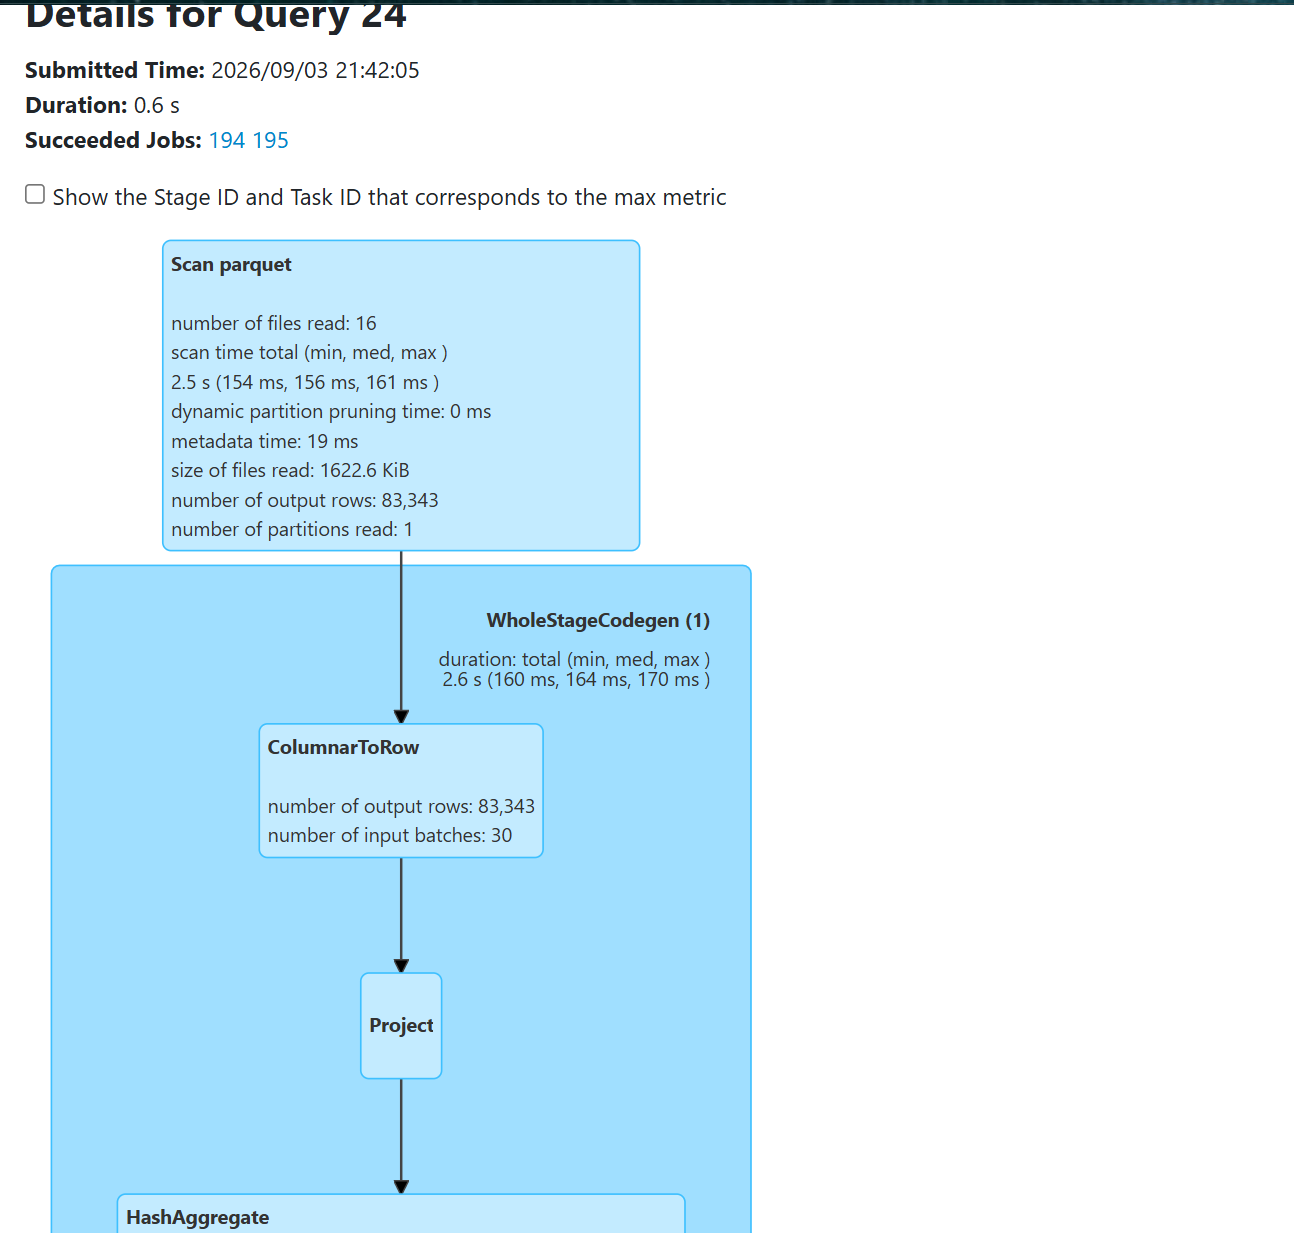

## Spark Justification

Spark fits this workload because the combined fact table is over a million rows and the analysis
involves multiple wide joins, groupings, and aggregations across all of it - exactly the kind of
work that benefits from being expressed as a distributed DataFrame pipeline rather than a single-
threaded Pandas script, even though everything here runs on one machine in local mode. The same
code would scale out to a real cluster without changes if the dataset grew from a million rows to
billions, because the transformations (joins, groupBy/agg, filters) are all expressed as lazy
DataFrame operations that Spark's Catalyst optimiser can plan and parallelise across partitions.
The partitioning exercise above shows the other side of that: laying data out by a column that's
commonly filtered on (year/month here) lets Spark skip whole partitions at read time instead of
scanning everything, which matters far more once a dataset no longer fits comfortably in memory
on one node. The trade-off is overhead - starting a JVM, planning a distributed job, and shuffling
data across partitions all cost more than a plain Pandas `groupby()` on a dataset this size, so for
a one-off million-row analysis Spark's setup cost is arguably not worth it; it earns its keep once
the data (or the pipeline that has to run repeatedly) grows past what fits in one process's memory,
or once the same job needs to run across a cluster rather than a single laptop.

In [19]:
spark.stop()